# Grid views — 3 lectures complémentaires + analyses additionnelles

Chaque vue répond à une question différente :
- **Grokking step** : où sont les sweet spots et quelle vitesse absolue ?
- **Phase** : ça grok oui/non ?
- **Grokking gap** : combien de temps entre mémo et généralisation ?

Plus :
- Training curves overlay (3 optimiseurs au même point)
- Phase boundary scatter (frontière groké/non, 3 optims superposés)
- Scatter eg_med vs gap (un point par run, coloré par optim)
- Heatmap ratios de speedup

Données : `runs/grid_clean/{egd_hybrid, muon_hybrid, muon_no_mom, adamw}/`

## Setup

In [1]:
import json, math, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm, ListedColormap

%matplotlib inline
plt.rcParams.update({'figure.facecolor':'white','figure.dpi':100,'savefig.dpi':200,'font.size':11})
sns.set_style('whitegrid')

ROOT     = Path('/Users/mverest/Desktop/fourier/Opti_ML/baseline')
GRID_DIR = ROOT / 'runs' / 'grid_clean'
FIG_DIR  = ROOT / 'figs_views'
FIG_DIR.mkdir(exist_ok=True)

ACC_THRESH = 0.99

OPTIMS = {
    'EGD': {
        'subdir': 'egd_hybrid',
        'keys':   ['lr_egd', 'wd_egd', 'momentum_egd'],
        'color':  '#1f77b4',  # blue
        'marker': 'o',
    },
    'Muon': {
        'subdir': 'muon_hybrid',
        'keys':   ['lr_muon', 'wd_muon'],
        'color':  '#2ca02c',  # green
        'marker': 's',
    },
    'Muon_no_mom': {
        'subdir': 'muon_no_mom',
        'keys':   ['lr_muon', 'wd_muon'],
        'color':  '#17becf',  # teal
        'marker': 'D',
    },
    'AdamW': {
        'subdir': 'adamw',
        'keys':   ['lr_adamw', 'wd_adamw'],
        'aliases': {'lr_adamw':['lr_adamw','lr'], 'wd_adamw':['wd_adamw','weight_decay']},
        'color':  '#ff7f0e',  # orange
        'marker': '^',
    },
}
for name, cfg in OPTIMS.items():
    cfg['root'] = GRID_DIR / cfg['subdir']
    print(f'{name:14s} root exists: {cfg["root"].exists()}')

EGD            root exists: True
Muon           root exists: True
Muon_no_mom    root exists: True
AdamW          root exists: True


In [2]:
def first_above(epochs, vals, thresh):
    for e, v in zip(epochs, vals):
        if v >= thresh: return e
    return None

def load_seed(seed_dir):
    h = json.load(open(seed_dir / 'history.json'))
    return {'history': h,
            'mem':  first_above(h['epoch'], h['train_acc'], ACC_THRESH),
            'grok': first_above(h['epoch'], h['test_acc'],  ACC_THRESH),
            'last_test_acc': h['test_acc'][-1]}

def parse_combo(name, keys, aliases=None):
    out = {}
    for tok in name.split('__'):
        for k in keys:
            if k in out: continue
            prefixes = aliases.get(k, [k]) if aliases else [k]
            prefixes = sorted(prefixes, key=len, reverse=True)
            matched = False
            for pfx in prefixes:
                if tok.startswith(pfx):
                    try: out[k] = float(tok[len(pfx):]); matched = True; break
                    except ValueError: continue
            if matched: break
    return out

def load_grid(root, keys, aliases=None):
    rows = []
    if not Path(root).exists(): return rows
    for cdir in sorted(Path(root).iterdir()):
        if not cdir.is_dir(): continue
        params = parse_combo(cdir.name, keys, aliases)
        if len(params) < len(keys): continue
        for sd in sorted(cdir.iterdir()):
            if sd.name.startswith('seed') and (sd/'history.json').exists():
                rec = load_seed(sd)
                rec.update(params)
                rec['seed']  = int(sd.name.replace('seed',''))
                rec['combo'] = cdir.name
                rows.append(rec)
    return rows

def aggregate(rows, keys):
    if not rows: return pd.DataFrame(columns=keys+['n_seeds','n_grok','eg_med','mem_med','gap_med','grok_rate'])
    df = pd.DataFrame(rows)
    g = df.groupby(keys).agg(
        n_seeds=('seed','count'),
        n_grok=('grok', lambda x: x.notna().sum()),
        eg_med=('grok', lambda x: x.dropna().median()),
        mem_med=('mem', lambda x: x.dropna().median()),
        final_acc=('last_test_acc','median'),
    ).reset_index()
    g['grok_rate'] = g['n_grok']/g['n_seeds']
    g['gap_med'] = g['eg_med'] - g['mem_med']
    return g

for name, cfg in OPTIMS.items():
    cfg['rows'] = load_grid(cfg['root'], cfg['keys'], cfg.get('aliases'))
    cfg['df']   = aggregate(cfg['rows'], cfg['keys'])
    n_grok = int(cfg['df']['n_grok'].sum()) if len(cfg['df']) else 0
    print(f'{name:14s} : {len(cfg["rows"]):3d} runs, {len(cfg["df"]):3d} combos, {n_grok} grokké(s)')

EGD            : 100 runs,  50 combos, 33 grokké(s)
Muon           :  49 runs,  25 combos, 12 grokké(s)
Muon_no_mom    :  50 runs,  25 combos, 19 grokké(s)
AdamW          :  50 runs,  25 combos, 8 grokké(s)


## VUE 1 — Grokking step (eg_med)
Sweet spots et vitesses absolues. Couleur = log(eg_med), ✗ = pas grok.

/opt/homebrew/Caskroom/miniconda/base/envs/stat_env/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/homebrew/Caskroom/miniconda/base/envs/stat_env/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/homebrew/Caskroom/miniconda/base/envs/stat_env/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/homebrew/Caskroom/miniconda/base/envs/stat_env/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.draw()
/var/folders/t_/qjzw0tfs4c1b4y9_lbr0j6x00000gn/T/ipykernel_57055/2700178402.py:35: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/t_/qjzw0tfs4c1b4y9_lbr0j6x00000gn/T/ipykernel_57055/270

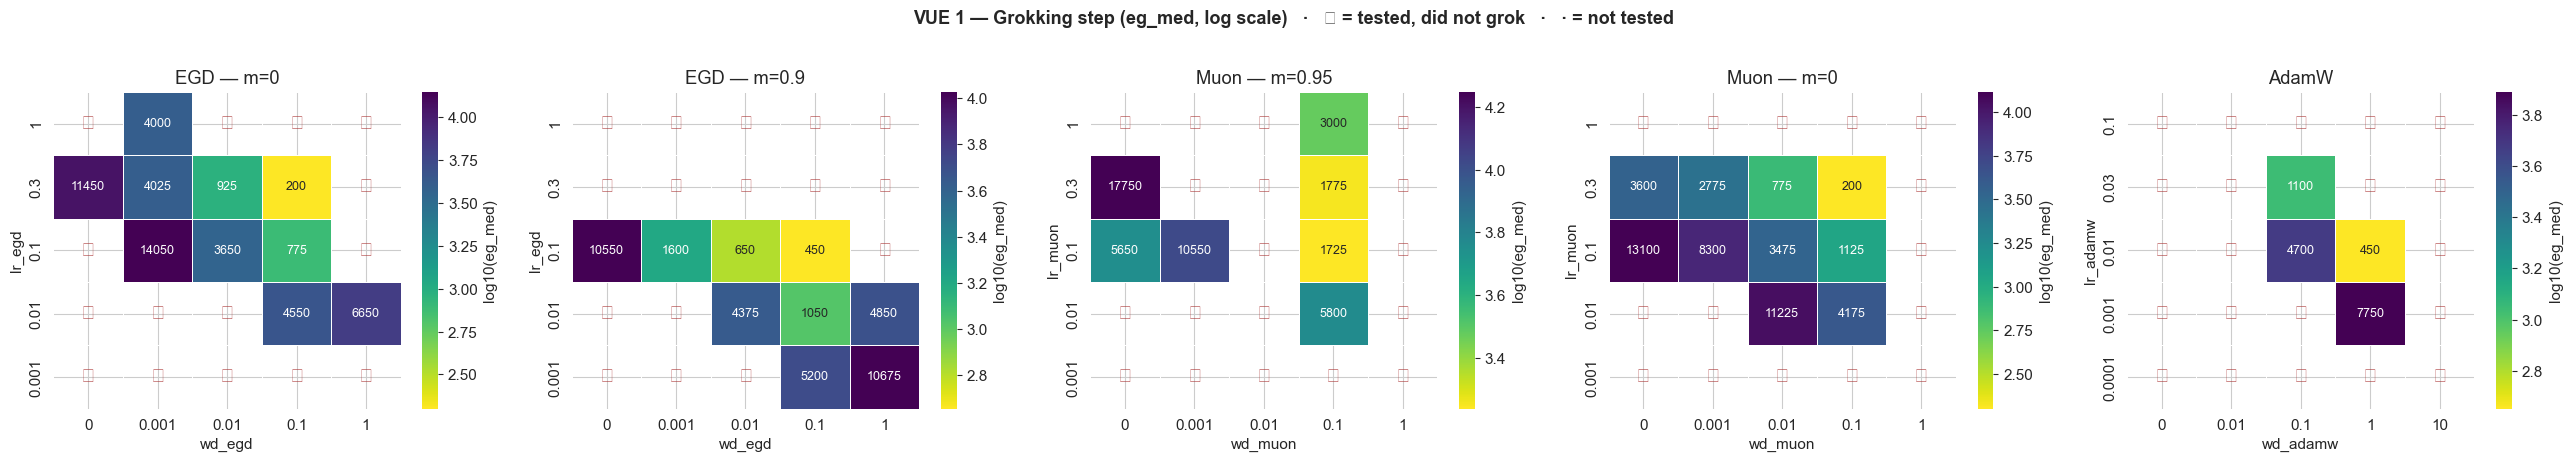

In [3]:
def heatmap_panel(ax, df, x_key, y_key, title, value='eg_med', fixed=None,
                  log=True, vmin=None, vmax=None, cmap='viridis_r', fmt='.0f',
                  cbar_label=None, show_x=False):
    sub = df if fixed is None else df.query(' and '.join(f'{k}=={v}' for k,v in fixed.items()))
    piv = sub.pivot(index=y_key, columns=x_key, values=value).sort_index(ascending=False)
    vals = np.log10(piv.values) if log else piv.values
    tested = set(map(tuple, sub[[y_key, x_key]].values))
    untested = np.array([[(y, x) not in tested for x in piv.columns] for y in piv.index])
    nogrok = np.isnan(piv.values) & ~untested if value == 'eg_med' else np.zeros_like(piv.values, dtype=bool)
    mask = untested | nogrok
    if vmin is None: vmin = np.nanmin(vals)
    if vmax is None: vmax = np.nanmax(vals)
    label = cbar_label or (f'log10({value})' if log else value)
    sns.heatmap(vals, ax=ax, mask=mask, cmap=cmap, vmin=vmin, vmax=vmax,
                annot=piv.values, fmt=fmt, cbar=True,
                cbar_kws={'label': label},
                xticklabels=[f'{c:g}' for c in piv.columns],
                yticklabels=[f'{i:g}' for i in piv.index],
                linewidths=0.5, linecolor='white', annot_kws={'fontsize':9})
    for i, j in zip(*np.where(nogrok)):
        ax.text(j+0.5, i+0.5, '✗', ha='center', va='center', color='#aa3333', fontsize=14, fontweight='bold')
    for i, j in zip(*np.where(untested)):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, facecolor='#f5f5f5', edgecolor='white', lw=0.5))
        ax.text(j+0.5, i+0.5, '·', ha='center', va='center', color='#999999', fontsize=14)
    ax.set_title(title); ax.set_xlabel(x_key); ax.set_ylabel(y_key)

fig, axes = plt.subplots(1, 5, figsize=(26, 4.5))
heatmap_panel(axes[0], OPTIMS['EGD']['df'],         'wd_egd',   'lr_egd',   'EGD — m=0',     fixed={'momentum_egd':0.0})
heatmap_panel(axes[1], OPTIMS['EGD']['df'],         'wd_egd',   'lr_egd',   'EGD — m=0.9',   fixed={'momentum_egd':0.9})
heatmap_panel(axes[2], OPTIMS['Muon']['df'],        'wd_muon',  'lr_muon',  'Muon — m=0.95')
heatmap_panel(axes[3], OPTIMS['Muon_no_mom']['df'], 'wd_muon',  'lr_muon',  'Muon — m=0')
heatmap_panel(axes[4], OPTIMS['AdamW']['df'],       'wd_adamw', 'lr_adamw', 'AdamW')
plt.suptitle('VUE 1 — Grokking step (eg_med, log scale)   ·   ✗ = tested, did not grok   ·   · = not tested',
             y=1.02, fontsize=13, fontweight='600')
plt.tight_layout()
plt.savefig(FIG_DIR / 'view1_grokking_step.png', bbox_inches='tight')
plt.show()

## VUE 2 — Phase (binary grok / no grok)
Question : ça grok oui ou non ? Lecture immédiate. Frontière grise/verte = `wd_min` effectif.

/var/folders/t_/qjzw0tfs4c1b4y9_lbr0j6x00000gn/T/ipykernel_57055/1561963334.py:43: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/t_/qjzw0tfs4c1b4y9_lbr0j6x00000gn/T/ipykernel_57055/1561963334.py:43: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/t_/qjzw0tfs4c1b4y9_lbr0j6x00000gn/T/ipykernel_57055/1561963334.py:44: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / 'view2_phase_binary.png', bbox_inches='tight')
/var/folders/t_/qjzw0tfs4c1b4y9_lbr0j6x00000gn/T/ipykernel_57055/1561963334.py:44: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / 'view2_phase_binary.png', bbox_inches='tight')
/opt/homebrew/Caskroom/miniconda/base/envs/stat_env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(b

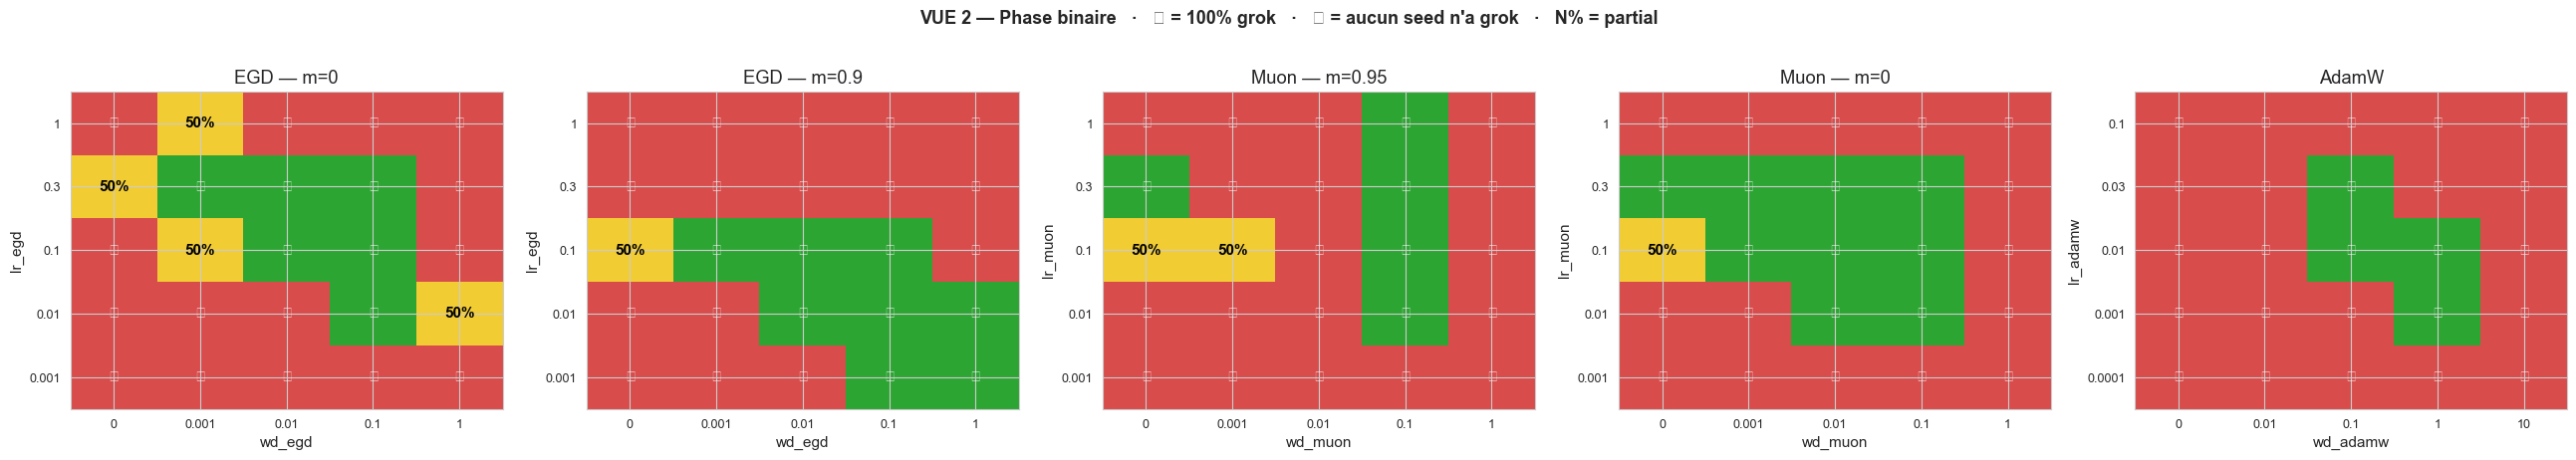

In [4]:
def heatmap_binary(ax, df, x_key, y_key, title, fixed=None):
    sub = df if fixed is None else df.query(' and '.join(f'{k}=={v}' for k,v in fixed.items()))
    piv_g = sub.pivot(index=y_key, columns=x_key, values='grok_rate').sort_index(ascending=False)
    tested = set(map(tuple, sub[[y_key, x_key]].values))
    untested = np.array([[(y, x) not in tested for x in piv_g.columns] for y in piv_g.index])
    grok = (piv_g.values >= 0.5) & ~untested   # majority of seeds grokked
    nogrok = (piv_g.values < 0.5) & ~np.isnan(piv_g.values) & ~untested
    partial = (piv_g.values > 0) & (piv_g.values < 1) & ~untested

    # Discrete colormap: gray = nogrok, yellow = partial, green = full grok
    rgb = np.full(piv_g.values.shape + (3,), 0.95, dtype=float)
    rgb[grok]   = [0.18, 0.65, 0.20]  # green
    rgb[nogrok] = [0.85, 0.30, 0.30]  # red
    rgb[partial] = [0.95, 0.80, 0.20] # yellow (50% grok rate)
    rgb[untested] = [0.96, 0.96, 0.96]
    ax.imshow(rgb, aspect='auto')
    for (i, j), v in np.ndenumerate(piv_g.values):
        if untested[i,j]:
            txt, c = '·', '#999'
        elif np.isnan(v):
            txt, c = '?', '#666'
        elif v >= 1.0:
            txt, c = '✓', 'white'
        elif v <= 0:
            txt, c = '✗', 'white'
        else:
            txt, c = f'{int(v*100)}%', 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=11, fontweight='bold', color=c)
    ax.set_xticks(range(piv_g.shape[1]))
    ax.set_xticklabels([f'{c:g}' for c in piv_g.columns], fontsize=9)
    ax.set_yticks(range(piv_g.shape[0]))
    ax.set_yticklabels([f'{i:g}' for i in piv_g.index], fontsize=9)
    ax.set_title(title); ax.set_xlabel(x_key); ax.set_ylabel(y_key)

fig, axes = plt.subplots(1, 5, figsize=(26, 4.5))
heatmap_binary(axes[0], OPTIMS['EGD']['df'],         'wd_egd',   'lr_egd',   'EGD — m=0',     fixed={'momentum_egd':0.0})
heatmap_binary(axes[1], OPTIMS['EGD']['df'],         'wd_egd',   'lr_egd',   'EGD — m=0.9',   fixed={'momentum_egd':0.9})
heatmap_binary(axes[2], OPTIMS['Muon']['df'],        'wd_muon',  'lr_muon',  'Muon — m=0.95')
heatmap_binary(axes[3], OPTIMS['Muon_no_mom']['df'], 'wd_muon',  'lr_muon',  'Muon — m=0')
heatmap_binary(axes[4], OPTIMS['AdamW']['df'],       'wd_adamw', 'lr_adamw', 'AdamW')
plt.suptitle('VUE 2 — Phase binaire   ·   ✓ = 100% grok   ·   ✗ = aucun seed n\'a grok   ·   N% = partial',
             y=1.02, fontsize=13, fontweight='600')
plt.tight_layout()
plt.savefig(FIG_DIR / 'view2_phase_binary.png', bbox_inches='tight')
plt.show()

## VUE 3 — Grokking gap (eg_med − mem_med)
Combien de temps entre mémorisation et généralisation ? Petit gap = grokking quasi-instantané.

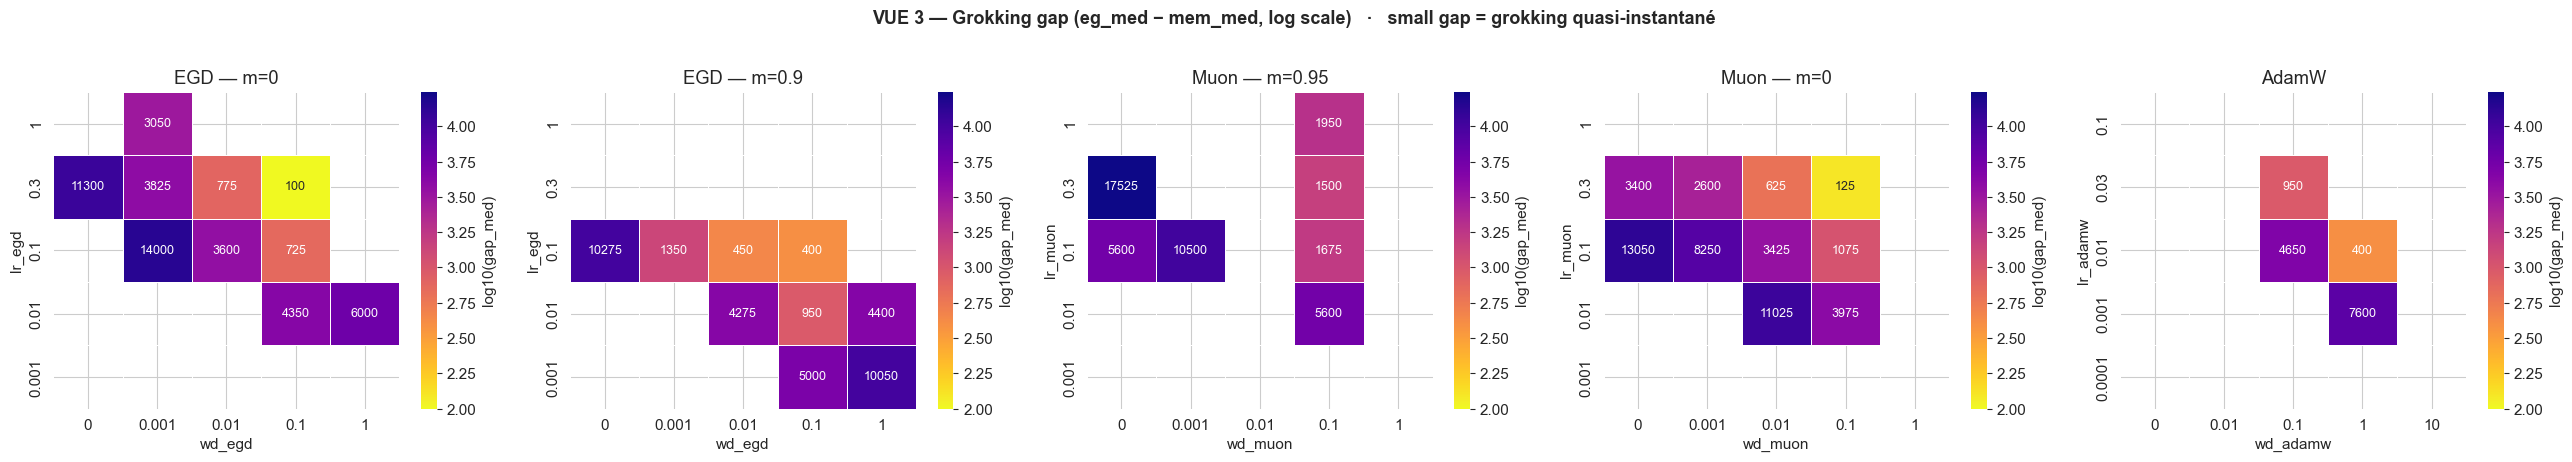

In [5]:
# Calcule globalement vmin/vmax pour comparabilité entre panels
all_gaps = []
for cfg in OPTIMS.values():
    all_gaps.extend(cfg['df']['gap_med'].dropna().values.tolist())
vmin_gap, vmax_gap = np.log10(max(1, min(all_gaps))), np.log10(max(all_gaps))

fig, axes = plt.subplots(1, 5, figsize=(26, 4.5))
heatmap_panel(axes[0], OPTIMS['EGD']['df'],         'wd_egd',   'lr_egd',   'EGD — m=0',     value='gap_med', fixed={'momentum_egd':0.0}, vmin=vmin_gap, vmax=vmax_gap, cmap='plasma_r', cbar_label='log10(gap_med)')
heatmap_panel(axes[1], OPTIMS['EGD']['df'],         'wd_egd',   'lr_egd',   'EGD — m=0.9',   value='gap_med', fixed={'momentum_egd':0.9}, vmin=vmin_gap, vmax=vmax_gap, cmap='plasma_r', cbar_label='log10(gap_med)')
heatmap_panel(axes[2], OPTIMS['Muon']['df'],        'wd_muon',  'lr_muon',  'Muon — m=0.95', value='gap_med', vmin=vmin_gap, vmax=vmax_gap, cmap='plasma_r', cbar_label='log10(gap_med)')
heatmap_panel(axes[3], OPTIMS['Muon_no_mom']['df'], 'wd_muon',  'lr_muon',  'Muon — m=0',    value='gap_med', vmin=vmin_gap, vmax=vmax_gap, cmap='plasma_r', cbar_label='log10(gap_med)')
heatmap_panel(axes[4], OPTIMS['AdamW']['df'],       'wd_adamw', 'lr_adamw', 'AdamW',         value='gap_med', vmin=vmin_gap, vmax=vmax_gap, cmap='plasma_r', cbar_label='log10(gap_med)')
plt.suptitle('VUE 3 — Grokking gap (eg_med − mem_med, log scale)   ·   small gap = grokking quasi-instantané',
             y=1.02, fontsize=13, fontweight='600')
plt.tight_layout()
plt.savefig(FIG_DIR / 'view3_grokking_gap.png', bbox_inches='tight')
plt.show()

## BONUS 1 — Courbes d'entraînement superposées (3 optims, plusieurs (lr, wd))
À (lr, wd) fixé, train/test acc des 3 optimiseurs hybrides. Permet de comparer la forme de la transition.

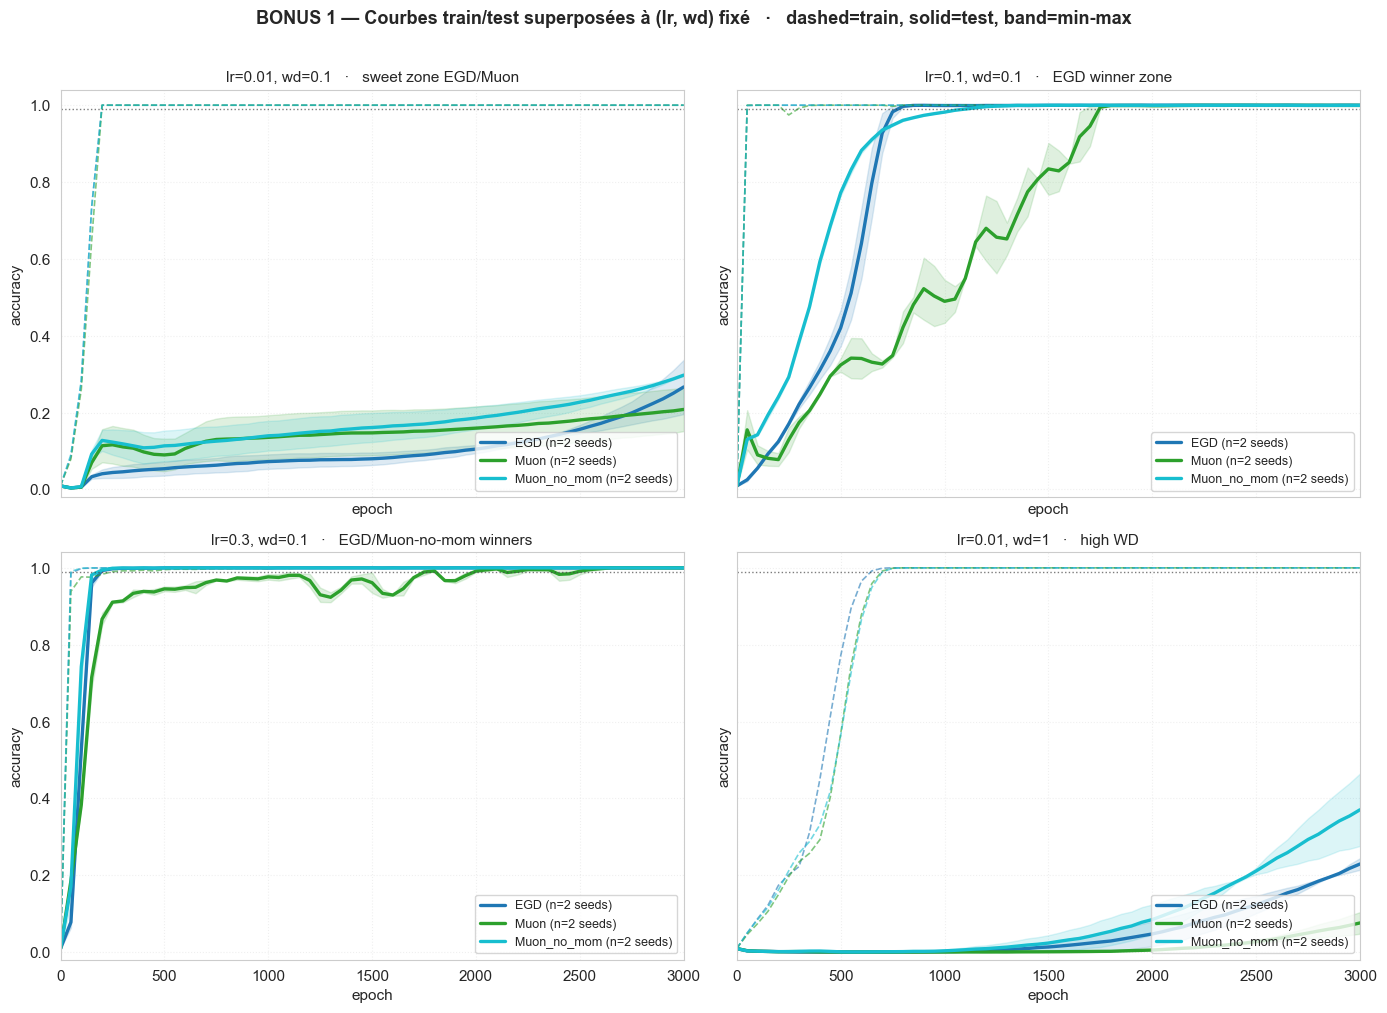

In [6]:
# Quelques points partagés (existent dans EGD, Muon, Muon_no_mom). Choisis 4 points intéressants.
SHARED_POINTS = [
    (1e-2, 1e-1, 'sweet zone EGD/Muon'),
    (1e-1, 1e-1, 'EGD winner zone'),
    (3e-1, 1e-1, 'EGD/Muon-no-mom winners'),
    (1e-2, 1.0,  'high WD'),
]
MAX_EPOCH = 3000

def stack(runs, key, max_epoch):
    arrays, epochs_ref = [], None
    for rec in runs:
        h = rec['history']
        ep, val = np.array(h['epoch']), np.array(h[key])
        mask = ep <= max_epoch
        ep, val = ep[mask], val[mask]
        if epochs_ref is None: epochs_ref = ep
        else:
            n = min(len(epochs_ref), len(ep))
            epochs_ref = epochs_ref[:n]
            arrays = [a[:n] for a in arrays]
            val = val[:n]
        arrays.append(val)
    if not arrays: return None, None
    return epochs_ref, np.stack(arrays, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True, sharex=True)
axes = axes.ravel()
OPTIMS_TO_OVERLAY = ['EGD', 'Muon', 'Muon_no_mom']   # AdamW a un grid lr différent, on l'exclut ici
for ax, (lr, wd, label) in zip(axes, SHARED_POINTS):
    for name in OPTIMS_TO_OVERLAY:
        cfg = OPTIMS[name]
        keys = cfg['keys']
        # extra filter for EGD: momentum=0 (default winner direction)
        extra = {'momentum_egd': 0.0} if name == 'EGD' else {}
        runs = [r for r in cfg['rows']
                if abs(r[keys[0]]-lr)<1e-12 and abs(r[keys[1]]-wd)<1e-12
                and all(abs(r.get(k, v))-v < 1e-12 for k, v in extra.items())]
        if not runs:
            ax.plot([], [], color=cfg['color'], lw=2, label=f'{name} (n/a)')
            continue
        eps, train = stack(runs, 'train_acc', MAX_EPOCH)
        _,   test  = stack(runs, 'test_acc',  MAX_EPOCH)
        c = cfg['color']
        ax.fill_between(eps, test.min(0), test.max(0), color=c, alpha=0.15)
        ax.plot(eps, train.mean(0), color=c, ls='--', lw=1.2, alpha=0.6)
        ax.plot(eps, test.mean(0),  color=c, ls='-',  lw=2.4,
                label=f'{name} (n={len(runs)} seeds)')
    ax.axhline(0.99, color='#444', ls=':', lw=1, alpha=0.7)
    ax.set_title(f'lr={lr:g}, wd={wd:g}   ·   {label}', fontsize=11)
    ax.set_xlabel('epoch'); ax.set_ylabel('accuracy')
    ax.set_ylim(-0.02, 1.04); ax.set_xlim(0, MAX_EPOCH)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle=':')

plt.suptitle('BONUS 1 — Courbes train/test superposées à (lr, wd) fixé   ·   dashed=train, solid=test, band=min-max',
             y=1.01, fontsize=13, fontweight='600')
plt.tight_layout()
plt.savefig(FIG_DIR / 'bonus1_curves_overlay.png', bbox_inches='tight')
plt.show()

## BONUS 2 — Phase boundary scatter (3 frontières superposées)
Tous les optims sur le même panel. Marqueur = optim, couleur = grok/no-grok.

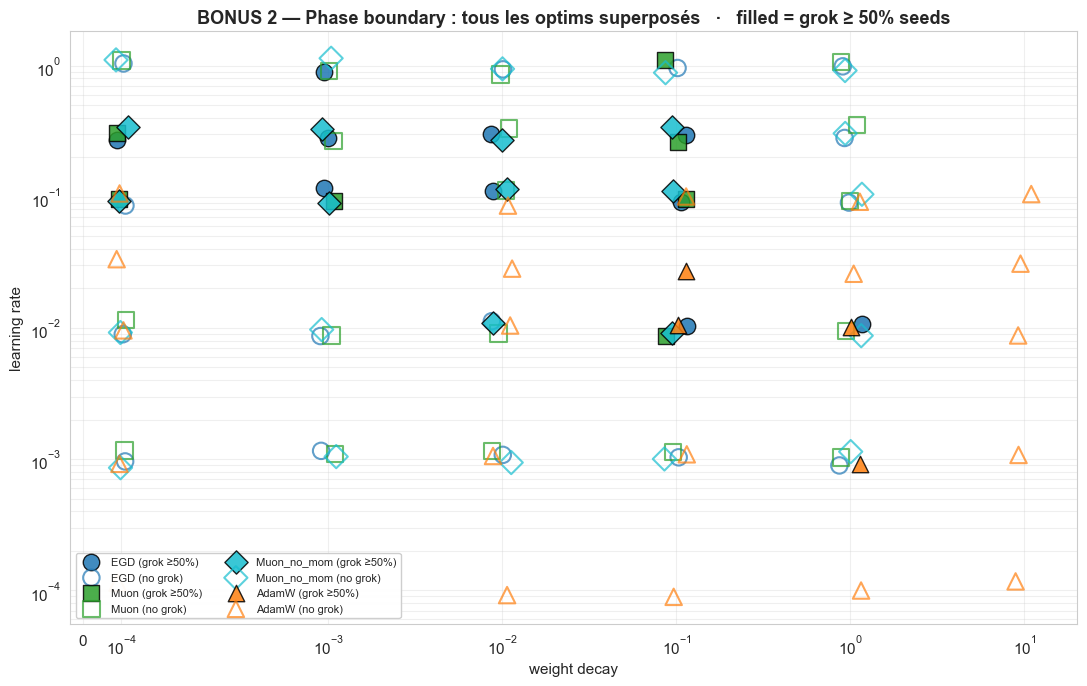

In [7]:
fig, ax = plt.subplots(figsize=(11, 7))

JITTER = 0.07  # un peu de bruit pour séparer les markers superposés
np.random.seed(42)

for name, cfg in OPTIMS.items():
    df = cfg['df'].copy()
    keys = cfg['keys']
    # Pour EGD : on prend seulement momentum=0 pour ne pas avoir 2 nuages
    if 'momentum_egd' in keys:
        df = df[df['momentum_egd'] == 0.0]
    lr_key = [k for k in keys if k.startswith('lr_')][0]
    wd_key = [k for k in keys if k.startswith('wd_')][0]
    df['wd_plot'] = df[wd_key].replace(0, 1e-4)

    # Jitter en log-space pour éviter le chevauchement parfait
    log_lr = np.log10(df[lr_key]) + np.random.uniform(-JITTER, JITTER, len(df))
    log_wd = np.log10(df['wd_plot']) + np.random.uniform(-JITTER, JITTER, len(df))
    grok = df['grok_rate'] >= 0.5
    nogrok = ~grok

    # Plot grokké et no-grok avec même marker mais couleur différente
    ax.scatter(10**log_wd[grok], 10**log_lr[grok],
               marker=cfg['marker'], s=140, c=cfg['color'],
               edgecolor='black', linewidth=1.0, alpha=0.85,
               label=f'{name} (grok ≥50%)')
    ax.scatter(10**log_wd[nogrok], 10**log_lr[nogrok],
               marker=cfg['marker'], s=140, facecolor='none',
               edgecolor=cfg['color'], linewidth=1.5, alpha=0.7,
               label=f'{name} (no grok)')

ax.set_xscale('symlog', linthresh=5e-4)
ax.set_yscale('log')
ax.set_xlabel('weight decay'); ax.set_ylabel('learning rate')
ax.set_title('BONUS 2 — Phase boundary : tous les optims superposés   ·   filled = grok ≥ 50% seeds',
             fontsize=13, fontweight='600')
ax.legend(loc='lower left', fontsize=8, ncol=2, framealpha=0.95)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'bonus2_phase_boundary.png', bbox_inches='tight')
plt.show()

## BONUS 3 — Scatter eg_med vs gap_med (un point par combo)
Révèle si certains runs "grokent tôt mais avec long gap" vs "grokent tard mais saut brusque après mémo".

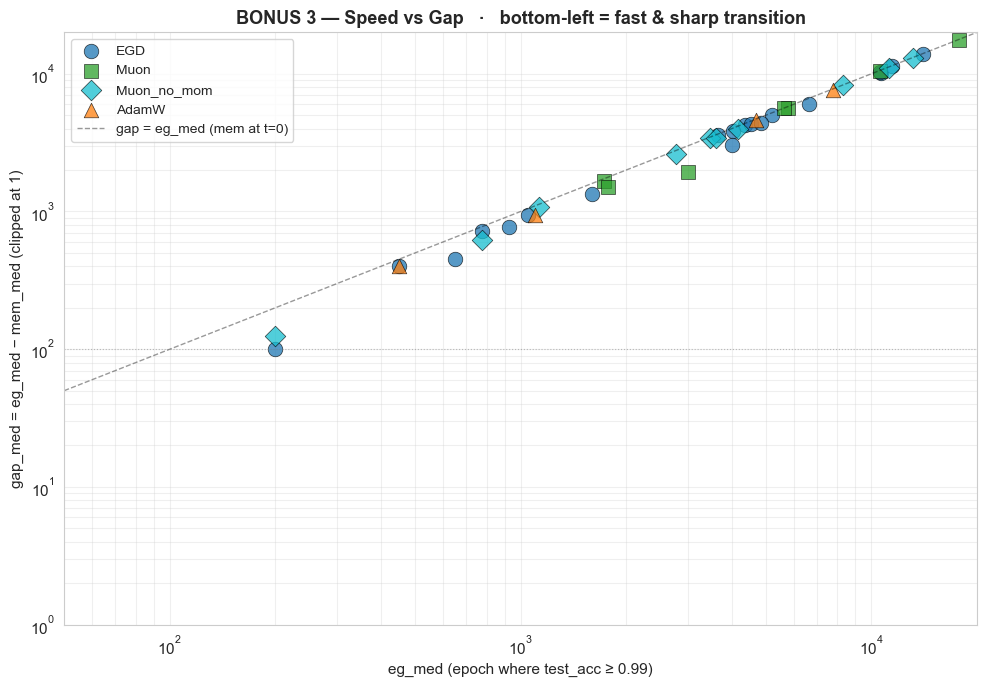

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
for name, cfg in OPTIMS.items():
    sub = cfg['df'].dropna(subset=['eg_med', 'gap_med'])
    if sub.empty: continue
    ax.scatter(sub['eg_med'], sub['gap_med'].clip(lower=1),
               marker=cfg['marker'], s=110, c=cfg['color'],
               edgecolor='black', linewidth=0.5, alpha=0.75, label=name)
# diagonale gap = eg_med (mem = 0, grokking immediate)
lim = [50, 20000]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.4, label='gap = eg_med (mem at t=0)')
# horizontale gap = 100 (faible)
ax.axhline(100, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lim); ax.set_ylim([1, lim[1]])
ax.set_xlabel('eg_med (epoch where test_acc ≥ 0.99)')
ax.set_ylabel('gap_med = eg_med − mem_med (clipped at 1)')
ax.set_title('BONUS 3 — Speed vs Gap   ·   bottom-left = fast & sharp transition',
             fontsize=13, fontweight='600')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'bonus3_speed_vs_gap.png', bbox_inches='tight')
plt.show()

## BONUS 4 — Heatmap ratios de speedup (Muon vs AdamW, EGD vs AdamW)
Pour chaque (lr, wd) où les DEUX optims grokent, on affiche le ratio eg_med_adamw / eg_med_X. Ratio > 1 = X est plus rapide.

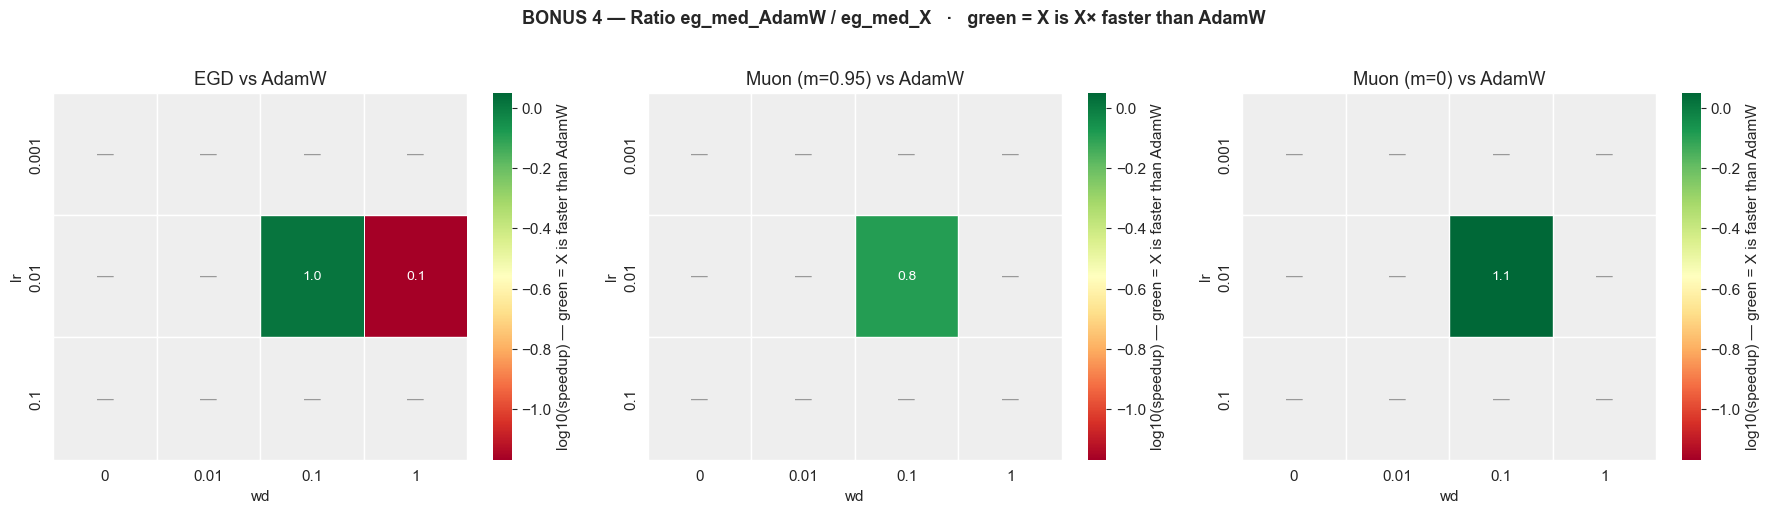

In [9]:
# Pour le ratio, on a besoin de configs partagées. Comme AdamW a un grid lr différent,
# on travaille dans l'intersection lr ∈ {1e-3, 1e-2, 1e-1} et wd ∈ {0, 1e-2, 1e-1, 1.0}.
SHARED_LR = [1e-3, 1e-2, 1e-1]
SHARED_WD = [0, 1e-2, 1e-1, 1.0]

def get_eg_table(df, lr_key, wd_key, fixed=None):
    sub = df if fixed is None else df.query(' and '.join(f'{k}=={v}' for k,v in fixed.items()))
    return sub.set_index([lr_key, wd_key])['eg_med']

tab_adamw  = get_eg_table(OPTIMS['AdamW']['df'],       'lr_adamw', 'wd_adamw')
tab_egd    = get_eg_table(OPTIMS['EGD']['df'],         'lr_egd',   'wd_egd', fixed={'momentum_egd':0.0})
tab_muon   = get_eg_table(OPTIMS['Muon']['df'],        'lr_muon',  'wd_muon')
tab_muon_n = get_eg_table(OPTIMS['Muon_no_mom']['df'], 'lr_muon',  'wd_muon')

def ratio_grid(tab_X, tab_ref):
    grid = np.full((len(SHARED_LR), len(SHARED_WD)), np.nan)
    for i, lr in enumerate(SHARED_LR):
        for j, wd in enumerate(SHARED_WD):
            key = (lr, wd)
            if key in tab_X.index and key in tab_ref.index:
                eg_x, eg_ref = tab_X.loc[key], tab_ref.loc[key]
                if pd.notna(eg_x) and pd.notna(eg_ref):
                    grid[i, j] = eg_ref / eg_x   # > 1 = X est plus rapide
    return grid

ratios = [
    ('EGD vs AdamW',          ratio_grid(tab_egd,    tab_adamw)),
    ('Muon (m=0.95) vs AdamW', ratio_grid(tab_muon,   tab_adamw)),
    ('Muon (m=0) vs AdamW',    ratio_grid(tab_muon_n, tab_adamw)),
]

all_vals = np.concatenate([r[1].flatten() for r in ratios])
vmin, vmax = np.log10(np.nanmin(all_vals[all_vals > 0])), np.log10(np.nanmax(all_vals))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, r) in zip(axes, ratios):
    log_r = np.log10(r)
    sns.heatmap(log_r, ax=ax, cmap='RdYlGn', vmin=vmin, vmax=vmax,
                annot=r, fmt='.1f', cbar=True,
                cbar_kws={'label':'log10(speedup) — green = X is faster than AdamW'},
                xticklabels=[f'{w:g}' for w in SHARED_WD],
                yticklabels=[f'{l:g}' for l in SHARED_LR],
                linewidths=0.5, linecolor='white', annot_kws={'fontsize':10},
                mask=np.isnan(log_r))
    for i, j in zip(*np.where(np.isnan(r))):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, facecolor='#eee', edgecolor='white'))
        ax.text(j+0.5, i+0.5, '—', ha='center', va='center', color='#999', fontsize=12)
    ax.set_title(title); ax.set_xlabel('wd'); ax.set_ylabel('lr')
plt.suptitle('BONUS 4 — Ratio eg_med_AdamW / eg_med_X   ·   green = X is X× faster than AdamW',
             y=1.02, fontsize=13, fontweight='600')
plt.tight_layout()
plt.savefig(FIG_DIR / 'bonus4_speedup_ratio.png', bbox_inches='tight')
plt.show()

In [10]:
print(f'\n  All figures saved to {FIG_DIR}/')


  All figures saved to /Users/mverest/Desktop/fourier/Opti_ML/baseline/figs_views/
